In [1]:
import pandas as pd

# Загружаем данные
file_path = "london.csv"
df = pd.read_csv(file_path)

# Выведем общую информацию о данных
df.info()

# Проверим количество пропусков
missing_values = df.isnull().sum()

# Выведем первые несколько строк
df.head(), missing_values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     17414 non-null  object 
 1   cnt           17414 non-null  int64  
 2   t1            17414 non-null  float64
 3   t2            17414 non-null  float64
 4   hum           17414 non-null  float64
 5   wind_speed    17414 non-null  float64
 6   weather_code  17414 non-null  float64
 7   is_holiday    17414 non-null  float64
 8   is_weekend    17414 non-null  float64
 9   season        17414 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 1.3+ MB


(             timestamp  cnt   t1   t2    hum  wind_speed  weather_code  \
 0  2015-01-04 00:00:00  182  3.0  2.0   93.0         6.0           3.0   
 1  2015-01-04 01:00:00  138  3.0  2.5   93.0         5.0           1.0   
 2  2015-01-04 02:00:00  134  2.5  2.5   96.5         0.0           1.0   
 3  2015-01-04 03:00:00   72  2.0  2.0  100.0         0.0           1.0   
 4  2015-01-04 04:00:00   47  2.0  0.0   93.0         6.5           1.0   
 
    is_holiday  is_weekend  season  
 0         0.0         1.0     3.0  
 1         0.0         1.0     3.0  
 2         0.0         1.0     3.0  
 3         0.0         1.0     3.0  
 4         0.0         1.0     3.0  ,
 timestamp       0
 cnt             0
 t1              0
 t2              0
 hum             0
 wind_speed      0
 weather_code    0
 is_holiday      0
 is_weekend      0
 season          0
 dtype: int64)

In [2]:
# Преобразуем timestamp в datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Приведем категориальные переменные к int
categorical_columns = ["weather_code", "is_holiday", "is_weekend", "season"]
df[categorical_columns] = df[categorical_columns].astype(int)

# Проверим изменения
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     17414 non-null  datetime64[ns]
 1   cnt           17414 non-null  int64         
 2   t1            17414 non-null  float64       
 3   t2            17414 non-null  float64       
 4   hum           17414 non-null  float64       
 5   wind_speed    17414 non-null  float64       
 6   weather_code  17414 non-null  int64         
 7   is_holiday    17414 non-null  int64         
 8   is_weekend    17414 non-null  int64         
 9   season        17414 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(5)
memory usage: 1.3 MB


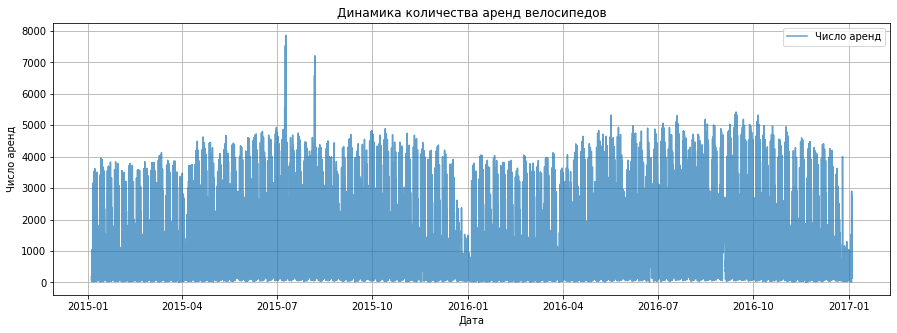

In [3]:
import matplotlib.pyplot as plt

# Построим график количества аренд по времени
plt.figure(figsize=(15, 5))
plt.plot(df["timestamp"], df["cnt"], label="Число аренд", color="tab:blue", alpha=0.7)
plt.xlabel("Дата")
plt.ylabel("Число аренд")
plt.title("Динамика количества аренд велосипедов")
plt.legend()
plt.grid(True)
plt.show()

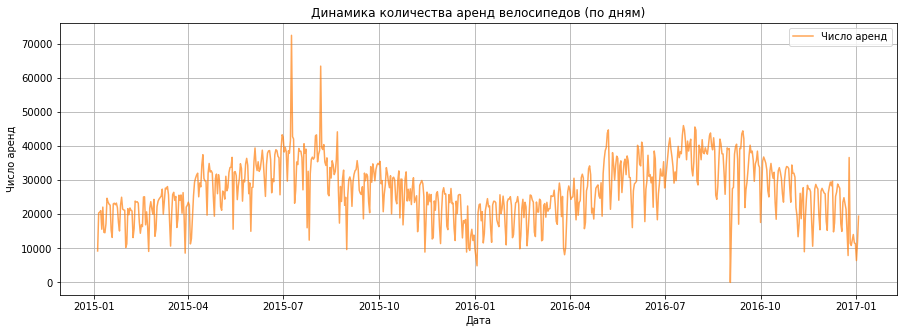

In [4]:
# Агрегируем данные по дням
df_daily = df.resample("D", on="timestamp").sum()

# Строим график
plt.figure(figsize=(15, 5))
plt.plot(df_daily.index, df_daily["cnt"], label="Число аренд", color="tab:orange", alpha=0.7)
plt.xlabel("Дата")
plt.ylabel("Число аренд")
plt.title("Динамика количества аренд велосипедов (по дням)")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
# Считаем скользящее среднее с окном 3
df_daily["rolling_mean_3"] = df_daily["cnt"].rolling(window=3).mean()

# Получаем значение для 2015-07-09
rentals_2015_07_09 = round(df_daily.loc["2015-07-09", "rolling_mean_3"])
print(rentals_2015_07_09)

50705


In [6]:
import numpy as np

In [7]:
# Вычисляем разницу между наблюдаемыми и подсчитанными значениями
c = df_daily["cnt"] - df_daily["rolling_mean_3"]

# Считаем стандартное отклонение
std = np.std(c)

# Округляем до 2 знаков
std_rounded = round(std, 2)
print(std_rounded)

4558.59


In [8]:
# Определяем границы 99% доверительного интервала
df_daily["upper_bound"] = df_daily["rolling_mean_3"] + 2.576 * std
df_daily["lower_bound"] = df_daily["rolling_mean_3"] - 2.576 * std

# Получаем верхнюю границу для последнего наблюдения
last_upper_bound = round(df_daily["upper_bound"].iloc[-1], 2)
print(last_upper_bound)

24302.92


In [9]:
# Выбираем аномальные дни
anomalies = df_daily[df_daily["cnt"] > df_daily["upper_bound"]]

# Определяем день с наибольшим числом аренд
max_rentals_date = anomalies["cnt"].idxmax()
print(max_rentals_date.strftime("%Y-%m-%d"))

2015-07-09
